<a href="https://colab.research.google.com/github/ngubse/FS25-NTF/blob/main/Nicolas_Gubser_Mathematics_for_new_technologies_in_Finance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mathematics for new technologies in finance project
Author: Nicolas Gubser 21-937-230

Generate Training scenarios

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
#generate Brownian motion
def brownian_motion(n, dt, N):
    """
    Generate a sample path of Brownian motion.

    Parameters:
    n (int): Number of time steps.
    dt (float): Time increment.
    N (int): Number of paths to generate.

    Returns:
    np.ndarray: Sample path of Brownian motion.
    """


    # Generate random increments
    dW = np.random.normal(0, np.sqrt(dt), n*N).reshape(N,n)
    # Initialize the Brownian motion array
    W = np.zeros((N,n))
    # Compute the Brownian motion path
    for i in range(1,n):
        for j in range(N):
            W[j,i] = W[j,i-1] + dW[j,i-1]
    return W
brownian_motion(1000, 0.01, 6)

In [ ]:
#2D Euler Scheme
def euler_scheme_2d(V0_x,V0_y, V1_x,V1_y, V2_x, V2_y, T, dt, x0, y0,W_1,W_2,N):
  """
  Performs the Euler-Maruyama scheme for a 2D SDE.

  Args:
    V0: A vector field representing the drift term.
    V1: A vector field associated with W_1.
    V2: A vector field associated with W_2.
    T: The final time.
    dt: The time step.
    x0: The initial value of x.
    y0: The initial value of y.
    W_1: The first Brownian motion.
    W_2: The second Brownian motion.
    N : The number of paths to generate.
    Inc: The increments of the Brownian motions. Increment at i is x[i+1] - x[i].
  Returns:
    A tuple containing the time points, x values, and increments.
  """
  n = int(T / dt)
  t = np.linspace(0, T, n + 1)
  x = np.zeros((N,n+1))
  y = np.zeros((N,n+1))
  Inc = np.zeros((N,n+1))

  for j in range(N):
    x[j,0] = x0
    y[j,0] = y0

    #read out the increments of the brownian motions
    dW_1 = np.zeros(n)
    dW_2 = np.zeros(n)
    for i in range(n-1):
      dW_1[i] = W_1[j,i + 1] - W_1[j,i]
      dW_2[i] = W_2[j,i + 1] - W_2[j,i]

    #dW_1 = np.sqrt(dt) * np.random.normal(size=n)
    #dW_2 = np.sqrt(dt) * np.random.normal(size=n)

    for i in range(n):
      Inc[j,i+1] = V0_x(x[j,i], y[j,i], t[i]) * dt + V1_x(x[j,i], y[j,i], t[i]) * dW_1[i] + V2_x(x[j,i], y[j,i], t[i]) * dW_2[i]
      x[j,i + 1] = x[j,i] + Inc[j,i + 1]
      y[j,i + 1] = y[j,i] + V0_x(x[j,i], y[j,i], t[i]) * dt + V1_y(x[j,i], y[j,i], t[i]) * dW_1[i] + V2_y(x[j,i], y[j,i], t[i]) * dW_2[i]
  return t, x, Inc



# Black-Scholes model  
The SDE for the Black-Scholes model is given by
$$dS_t = S_t\mu dt + S_t\sigma W$$

In [ ]:
#Parameters for BS
mu = 0.2
sigma = 0.2

#Functions for the BS model
def V0_x_BS(x, y, t):
    return mu * x
def V1_x_BS(x, y, t):
    return sigma * x
def V2_x_BS(x, y, t):
    return 0

def V0_y_BS(x, y, t):
    return 0
def V1_y_BS(x, y, t):
    return 0
def V2_y_BS(x, y, t):
    return 0


#generate data for the BS model
t, BS_data, BS_inc = euler_scheme_2d(V0_x_BS, V0_y_BS, V1_x_BS, V1_y_BS, V2_x_BS, V2_y_BS, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N), brownian_motion(int(T/dt),dt,N),N)

for i in range(N):
    plt.plot(BS_data[i])  # Time is implied as [0, 1, ..., n-1]

plt.title('Sample Paths')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

# Heston model  
The SDE for the Heston model is given by
$$S_t = \mu S_t dt + S_t \sqrt(\nu_t) dW_1$$
$$d\sqrt(\nu) = -\beta \sqrt(\nu) + \delta dW_2 $$

Furthermore, If $B_1, B_2$ are two idependent Brownian motions, then $$W_1 = B_1$$ $$W_2 = \rho B_1 + \sqrt(1-\rho^2)B_2$$ are two Brownian motions with correlation $\rho$.

With the Euler Scheme, a problem can arise: If the step size is not chosen finely enough, $S_t$ may become negative. However, it is immediately clear from the SDE that this is impossible in the continuous model.

<ipython-input-8-eca8ba331d5e>:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


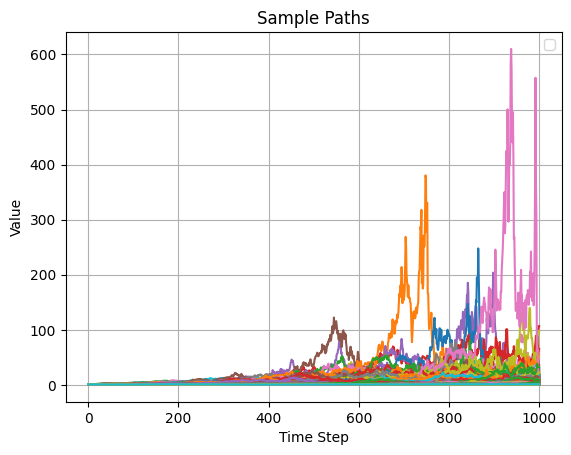

In [ ]:
#Heston model
#generate the two correlated Brownian motions
def W2(B_1,B_2,rho):
    """
    Generate the second Brownian motion W2 given W1 and correlation rho.

    Parameters:
    B_1 (np.ndarray): First Brownian motion.
    B_2 (np.ndarray): Second Brownian motion.
    rho (float): Correlation coefficient.

    Returns:
    np.ndarray: Second correlated Brownian motion.
    """
    return rho * B_1 + np.sqrt(1 - rho**2) * B_2


#Parameters for Heston model
mu = 0.2
beta = 0.2
delta = 0.3

#Functions for Heston model
def V0_x_heston(x, y, t):
    return mu * x
def V1_x_heston(x, y, t):
    return y * x
def V2_x_heston(x, y, t):
    return 0

def V0_y_heston(x, y, t):
    return -beta * y
def V1_y_heston(x, y, t):
    return delta
def V2_y_heston(x, y, t):
    return 0

#generate the Heston models, notice here y = sqrt(mu)
t, Heston_data, Heston_inc = euler_scheme_2d(V0_x_heston, V0_y_heston, V1_x_heston, V1_y_heston, V2_x_heston, V2_y_heston, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N), W2(brownian_motion(int(T/dt),dt,N),brownian_motion(int(T/dt),dt,N),0.5),N)


for i in range(N):
    plt.plot(Heston_data[i])  # Time is implied as [0, 1, ..., n-1]

plt.title('Sample Paths')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

# Constant elasticity of variance (CEV) model
The SDE is given by $$dS_t = \mu S_t dt + \sigma S_t^\gamma dW_t$$

<ipython-input-9-55af6a56fdb9>:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


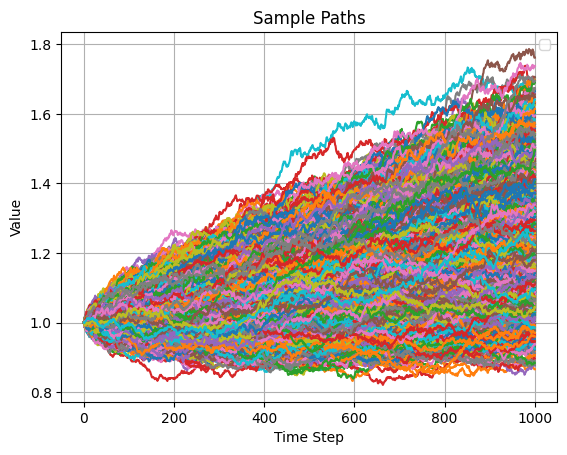

In [ ]:
#CEV model
#parameters for CEV
mu = 0.2
sigma = 0.1
gamma = 0.3

#Parameters for CEV model
def V0_x_CEV(x, y, t):
    return mu * x
def V1_x_CEV(x, y, t):
    return sigma * x**gamma
def V2_x_CEV(x, y, t):
    return 0

def V0_y_CEV(x, y, t):
    return 0
def V1_y_CEV(x, y, t):
    return 0
def V2_y_CEV(x, y, t):
    return 0


#Generate the CEV model
t, CEV_data, CEV_inc = euler_scheme_2d(V0_x_BS, V0_y_BS, V1_x_BS, V1_y_BS, V2_x_BS, V2_y_BS, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N), brownian_motion(int(T/dt),dt,N),N)

# Plotting the CEV model sample paths
for i in range(N):
    plt.plot(CEV_data[i])  # Time is implied as [0, 1, ..., n-1]

plt.title('Sample Paths')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

# Define a loss function

In this setting, we choose as a utility function for the definition of the loss function the exponential utility function $x \mapsto 1 - \frac{1}{\beta}\exp(-x\beta)$ for a given $\beta > 0$.
Maximizing over this utility function is equivalent to minimizing $$u \mapsto \exp(-\beta u)$$


In [ ]:
beta = 1 #risk aversion coefficient

class ExponentialUtilityLoss(nn.Module):
    def __init__(self, beta=1.0):
        """
        Exponential Utility Loss function, where:
        - beta is the risk aversion coefficient (higher beta means more risk aversion).
        - We minimize the negative exponential utility (which is equivalent to maximizing the utility).
        """
        super(ExponentialUtilityLoss, self).__init__()
        self.beta = beta  # risk aversion coefficient

    def forward(self, y_pred, y_true=None):
        """
        Loss function to compute the negative exponential utility of terminal wealth.

        Args:
        y_pred: Predicted terminal wealth (output from the model).
        y_true: The ground truth (not used in this context, but left here in case needed).

        Returns:
        Loss value: Average negative exponential utility over the batch.
        """
        # Compute exponential utility (negative of the utility function)
        utility = torch.exp(-self.beta * y_pred)  # negative exponential utility
        expected_utility = torch.mean(utility)  # expected utility across the batch

        #expected_utility_capped = torch.minimum(expected_utility, torch.tensor(10**3))
        #return expected_utility_capped

        return expected_utility  # Minimize this value to maximize the utility

# Model specification for the two trading agents

The Wealth process which we inspect consists

1. Bank account: $dB_t = r B_t dt$
2. Asset price given by an SDE: $S_t$

The Wealth process $X_t$ for a percentage $\alpha_t$ of stock in the portfolio at time t is then given by the equation
$$dX_t = \alpha_t \frac{X_t}{S_t}dS_t + (1-\alpha_t) \frac{X_t}{B_t}dB_t$$

If the discretization of T is chosen to coarsly, the path may become non-positive, this causes severe numerical instability in the two following trading agents especially in combination with data simulated by the Heston model.

<ipython-input-11-6e84a125366a>:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


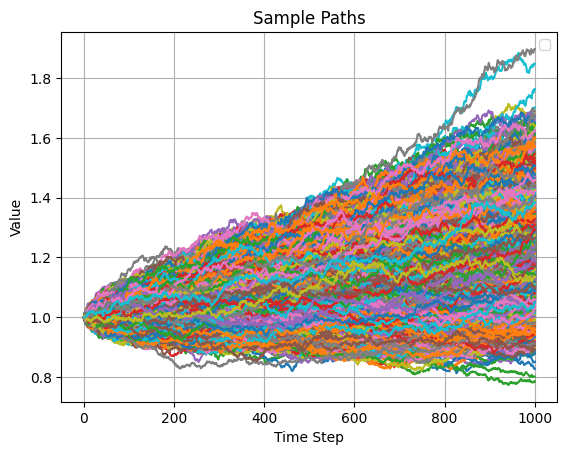

In [ ]:
#Global parameters
T = 1
dt = 0.001
N = 10**4 #number of paths
n = int(T / dt)
r = 0.05 #risk-free rate
epochs = 20

#Choose the model and generate the data
#t, BS_data, BS_inc = euler_scheme_2d(V0_x_BS, V0_y_BS, V1_x_BS, V1_y_BS, V2_x_BS, V2_y_BS, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N), brownian_motion(int(T/dt),dt,N),N)
#S = torch.from_numpy(BS_data).float()
#dS = torch.from_numpy(BS_inc).float()

#t, Heston_data, Heston_inc = euler_scheme_2d(V0_x_heston, V0_y_heston, V1_x_heston, V1_y_heston, V2_x_heston, V2_y_heston, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N), W2(brownian_motion(int(T/dt),dt,N),brownian_motion(int(T/dt),dt,N),0.5),N)
#S = torch.from_numpy(Heston_data).float()
#dS = torch.from_numpy(Heston_inc).float()

t, CEV_data, CEV_inc = euler_scheme_2d(V0_x_BS, V0_y_BS, V1_x_BS, V1_y_BS, V2_x_BS, V2_y_BS, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N), brownian_motion(int(T/dt),dt,N),N)
S = torch.from_numpy(CEV_data).float()
dS = torch.from_numpy(CEV_inc).float()

for i in range(N):
    plt.plot(S[i])  # Time is implied as [0, 1, ..., n-1]

plt.title('Sample Paths')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

# Markovian trader

The Markovian trader receives as information the current stock price, the wealth and time. This amounts to a closed loop.
We ensure the network at timestep t only receives information of said timestep t

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize weights to improve numerical stability
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

# Define the Markovian Trader model
class MarkovianTrader(nn.Module):
    def __init__(self, hidden_size=16, r=0.02, T=1.0, n_steps=50):
        super().__init__()
        self.r = r
        self.T = T
        self.n_steps = n_steps
        self.dt = T / n_steps

        # MLP: α_t = f(S_t, X_t)
        self.alpha_net = nn.Sequential(
            nn.Linear(2, hidden_size),  # input: [S_t, X_t]
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()  # keep α in (0, 1)
        )

    def forward(self, S: torch.Tensor, dS: torch.Tensor) -> torch.Tensor:
        """
        Args:
            S: [N, n] price paths
            dS: [N, n-1] price increments
        Returns:
            X: [N] final wealth
        """
        N, T_plus_1 = S.shape
        T = T_plus_1 - 1

        # Initialize wealth
        X = torch.ones(N, device=S.device)

        for t in range(T):
            S_t = S[:, t]            # [N]
            dS_t = dS[:, t]          # [N]
            R_t = dS_t / S_t         # [N]

            # Build input: [S_t, X_t]
            input_t = torch.stack([S_t, X], dim=-1)  # [N, 2]

            # Predict allocation α_t
            alpha_t = self.alpha_net(input_t).squeeze(-1)  # [N]

            # Compute dX_t from SDE
            dX_t = X * (alpha_t * R_t + (1 - alpha_t) * self.r * self.dt)  # [N]
            X = X + dX_t

        return X  # Final wealth



#Load training data
dataset = torch.utils.data.TensorDataset(S, dS)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

# Training
# Check for NaN of unreasonably high loss and restart training if necessary
# First, apply one epoch, if the loss is reasonable, continue training
# If the loss is NaN or unreasonably high, restart training
Unreasonable_loss = 1
while Unreasonable_loss == 1:
    model_Markovian= MarkovianTrader(n_steps=n, r=r).to(device)
    model_Markovian.apply(init_weights)
    loss_fn = ExponentialUtilityLoss(beta =beta).to(device)
    optimizer = torch.optim.Adam(model_Markovian.parameters(), lr=1e-4)

    for epoch in range(1):
        total_loss = 0.0
        for (S_batch, dS_batch) in loader:
            S_batch = S_batch.to(device)
            dS_batch = dS_batch.to(device)  # Move batch to device
            W_T = model_Markovian(S_batch, dS_batch)  # Compute terminal wealth for the batch

            # Compute the utility loss (this is where the backward call happens)
            loss = loss_fn(W_T)  # Loss is a scalar here

            optimizer.zero_grad()  # Zero gradients before backward pass
            loss.backward()        # Backpropagate loss on scalar value
            optimizer.step()       # Update model parameters

            total_loss += loss.item() * S_batch.size(0)  # Accumulate loss for the batch

        avg_loss = total_loss / len(dataset)  # Calculate average loss
        print(f"Epoch {epoch}, Avg Loss = {avg_loss:.6f}")
    if math.isnan(avg_loss):
        print("Loss became NaN. Restarting training...")
        Unreasonable_loss = 1
    elif avg_loss > 10:
        print("Loss is too high. Restarting training.")
        Unreasonable_loss = 1
    else:
        Unreasonable_loss = 0

# Continue training if the loss is reasonable
for epoch in range(1,epochs):
        total_loss = 0.0
        for (S_batch, dS_batch) in loader:
            S_batch = S_batch.to(device)
            dS_batch = dS_batch.to(device)  # Move batch to device
            W_T = model_Markovian(S_batch, dS_batch)  # Compute terminal wealth for the batch

            # Compute the utility loss (this is where the backward call happens)
            loss = loss_fn(W_T).to(device)  # Loss is a scalar here

            optimizer.zero_grad()  # Zero gradients before backward pass
            loss.backward()        # Backpropagate loss on scalar value
            optimizer.step()       # Update model parameters

            total_loss += loss.item() * S_batch.size(0)  # Accumulate loss for the batch

        avg_loss = total_loss / len(dataset)  # Calculate average loss
        print(f"Epoch {epoch}, Avg Loss = {avg_loss:.6f}")


Using device: cuda
Epoch 0, Avg Loss = 0.322223
Epoch 1, Avg Loss = 0.320437
Epoch 2, Avg Loss = 0.318638
Epoch 3, Avg Loss = 0.316907
Epoch 4, Avg Loss = 0.315233
Epoch 5, Avg Loss = 0.313601
Epoch 6, Avg Loss = 0.312043
Epoch 7, Avg Loss = 0.310598
Epoch 8, Avg Loss = 0.309287
Epoch 9, Avg Loss = 0.308122
Epoch 10, Avg Loss = 0.307105
Epoch 11, Avg Loss = 0.306228
Epoch 12, Avg Loss = 0.305476


# Path trader

The second trader receives the whole price and wealth process up to the current time. We denote this as the Path trader.
Here, we ensure the networt at time t sees information up to time t with a recurrent neural network.
Notice how only the architecture changes, not the training.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PathTrader(nn.Module):
    def __init__(self, input_size=2, hidden_size=16, r=0.02, T=1.0, n_steps=50):
        super().__init__()
        self.hidden_size = hidden_size
        self.r = r
        self.T = T
        self.n_steps = n_steps
        self.dt = T / n_steps

        # GRU processes [S_t, X_t] at each time step
        self.rnn = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)

        # MLP that maps hidden state to allocation α_t ∈ (0, 1)
        self.fc_alpha = nn.Sequential(
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, S, dS):
        """
        S:   [N, n_steps + 1] → prices S_0, ..., S_n
        dS:  [N, n_steps]     → price increments dS_1, ..., dS_n
        Returns:
            X_all: [N, n_steps + 1] wealth process X_0, ..., X_n
        """
        B, T_plus_1 = S.shape
        assert T_plus_1 == self.n_steps + 1
        T = self.n_steps

        # Initial wealth
        X_0 = torch.ones(B, 1, device=S.device)  # [N, 1]
        X_all = [X_0]

        input_seq = []

        for t in range(1, T + 1):
            S_t = S[:, t - 1].unsqueeze(-1)  # S_{t-1} for indexing (causal)
            X_t = X_all[-1]                  # X_{t-1}
            input_seq.append(torch.cat([S_t, X_t], dim=1))  # [N, 2]

        # Stack: [N, T, 2]
        input_seq = torch.stack(input_seq, dim=1)

        # GRU → hidden states
        h_seq, _ = self.rnn(input_seq)

        # Compute α_t from hidden states: [N, T]
        alpha_seq = self.fc_alpha(h_seq).squeeze(-1)

        # Simulate wealth over time using α_t and wealth dynamics
        X_t = X_0.squeeze(-1)  # shape: [N]
        X_trajectory = [X_t]

        for t in range(1, T + 1):
            S_t = S[:, t - 1]           # [N]
            dS_t = dS[:, t - 1]         # [N]
            alpha_t = alpha_seq[:, t - 1]  # [N]
            R_t = dS_t / S_t            # return

            dX_t = X_t * (alpha_t * R_t + (1 - alpha_t) * self.r * self.dt)
            X_t = X_t + dX_t

            X_trajectory.append(X_t)

        # Stack the trajectory: [N, T+1]
        X_all = torch.stack(X_trajectory, dim=1)

        return X_all  # Entire wealth path: [N, n_steps + 1]


#Weight_initialization (improves numerical stability)
def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

#prepare training data
dataset = torch.utils.data.TensorDataset(S, dS)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

model_Path= PathTrader(n_steps=n, r=r).to(device)
model_Path.apply(init_weights)
loss_fn = ExponentialUtilityLoss(beta =beta).to(device)
optimizer = torch.optim.Adam(model_Path.parameters(), lr=1e-4)

# Training
# Check for NaN of unreasonably high loss and restart training if necessary
# First, apply one epoch, if the loss is reasonable, continue training
# If the loss is NaN or unreasonably high, restart training
Unreasonable_loss = 1
while Unreasonable_loss == 1:
    model_Path.apply(init_weights)
    for epoch in range(1):
        total_loss = 0.0
        for (S_batch, dS_batch) in loader:
            S_batch = S_batch.to(device)
            dS_batch = dS_batch.to(device)  # Move batch to device
            W_T = model_Path(S_batch, dS_batch)  # Compute terminal wealth for the batch

            # Compute the utility loss (this is where the backward call happens)
            loss = loss_fn(W_T).to(device)  # Loss is a scalar here

            optimizer.zero_grad()  # Zero gradients before backward pass
            loss.backward()        # Backpropagate loss on scalar value
            optimizer.step()       # Update model parameters

            total_loss += loss.item() * S_batch.size(0)  # Accumulate loss for the batch

        avg_loss = total_loss / len(dataset)  # Calculate average loss
        print(f"Epoch {epoch}, Avg Loss = {avg_loss:.6f}")
    if math.isnan(avg_loss):
        print("Loss became NaN. Restarting training...")
        Unreasonable_loss = 1
    elif avg_loss > 10:
        print("Loss is too high. Restarting training.")
        Unreasonable_loss = 1
    else:
        Unreasonable_loss = 0

# Continue training if the loss is reasonable
for epoch in range(1,epochs):
        total_loss = 0.0
        for (S_batch, dS_batch) in loader:
            S_batch = S_batch.to(device)
            dS_batch = dS_batch.to(device)  # Move batch to device
            W_T = model_Path(S_batch, dS_batch)  # Compute terminal wealth for the batch

            # Compute the utility loss (this is where the backward call happens)
            loss = loss_fn(W_T).to(device)  # Loss is a scalar here

            optimizer.zero_grad()  # Zero gradients before backward pass
            loss.backward()        # Backpropagate loss on scalar value
            optimizer.step()       # Update model parameters

            total_loss += loss.item() * S_batch.size(0)  # Accumulate loss for the batch

        avg_loss = total_loss / len(dataset)  # Calculate average loss
        print(f"Epoch {epoch}, Avg Loss = {avg_loss:.6f}")

# Discussion

After training the model, we generate test date to evalutate if the models perform sufficiently well.

In [ ]:
#Generate test data
N_test = 100

#Choose the model and generate the data
#t, BS_data_test, BS_inc_test = euler_scheme_2d(V0_x_BS, V0_y_BS, V1_x_BS, V1_y_BS, V2_x_BS, V2_y_BS, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N_test), brownian_motion(int(T/dt),dt,N_test),N_test)
#S_test = torch.from_numpy(BS_data_test).float()
#dS_test = torch.from_numpy(BS_inc_test).float()

#t, Heston_data_test, Heston_inc_test = euler_scheme_2d(V0_x_heston, V0_y_heston, V1_x_heston, V1_y_heston, V2_x_heston, V2_y_heston, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N_test), W2(brownian_motion(int(T/dt),dt,N_test),brownian_motion(int(T/dt),dt,N_test),0.5),N_test)
#S_test = torch.from_numpy(Heston_data_test).float()
#dS_test = torch.from_numpy(Heston_inc_test).float()

t, CEV_data_test, CEV_inc_test = euler_scheme_2d(V0_x_BS, V0_y_BS, V1_x_BS, V1_y_BS, V2_x_BS, V2_y_BS, T, dt, 1, 1, brownian_motion(int(T/dt),dt,N_test), brownian_motion(int(T/dt),dt,N_test),N_test)
S_test = torch.from_numpy(CEV_data_test).float()
dS_test = torch.from_numpy(CEV_inc_test).float()


for i in range(N_test):
    plt.plot(S_test[i])  # Time is implied as [0, 1, ..., n-1]

plt.title('Sample Paths')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Create DataLoader for test data
test_dataset = torch.utils.data.TensorDataset(S_test, dS_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


#Evaluate Markovian trader
# Set model to evaluation mode
model_Markovian.eval()

# Collect final wealths from test data
all_wealths_Markovian = []

with torch.no_grad():  # Disable gradient tracking for evaluation
    for (S_batch, dS_batch) in test_loader:
        S_batch = S_batch.to(device)
        dS_batch = dS_batch.to(device)
        W_T = model_Markovian(S_batch, dS_batch)  # [batch_size]
        all_wealths_Markovian.append(W_T.cpu())  # Move to CPU for plotting

# Concatenate all batches into a single tensor
all_wealths_Markovian = torch.cat(all_wealths_Markovian).numpy()
print(all_wealths_Markovian.shape)

# Plot histogram of final wealth
plt.figure(figsize=(8, 5))
plt.hist(all_wealths_Markovian, bins=50, color='skyblue', edgecolor='black')

mean_wealth_Markovian = np.mean(all_wealths_Markovian)
plt.axvline(mean_wealth_Markovian, color='red', linestyle='dashed', linewidth=2, label=f'Mean = {mean_wealth_Markovian:.2f}')
plt.text(mean_wealth_Markovian, plt.ylim()[1] * 0.9, f'{mean_wealth_Markovian:.2f}', color='red', ha='center')


plt.title('Histogram of Final Wealth of a Markovian Trader')
plt.xlabel('Final Wealth')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

#Evaluate Path trader
# Set model to evaluation mode
model_Path.eval()

# Collect final wealths from test data
all_wealths_Path = []

with torch.no_grad():  # Disable gradient tracking for evaluation
    for (S_batch, dS_batch) in test_loader:
        S_batch = S_batch.to(device)
        dS_batch = dS_batch.to(device)
        W_all = model_Path(S_batch, dS_batch)  # [batch_size, T+1]
        W_T = W_all[:, -1]  # Final wealth at time T
        all_wealths_Path.append(W_T.cpu())  # Move to CPU for plotting

# Concatenate all batches into a single tensor
all_wealths_Path = torch.cat(all_wealths_Path).numpy()

# Plot histogram of final wealth
plt.figure(figsize=(8, 5))
plt.hist(all_wealths_Path, bins=50, color='orange', edgecolor='black')

mean_wealth_Path = np.mean(all_wealths_Path)
plt.axvline(mean_wealth_Path, color='red', linestyle='dashed', linewidth=2, label=f'Mean = {mean_wealth_Path:.2f}')
plt.text(mean_wealth_Path, plt.ylim()[1] * 0.9, f'{mean_wealth_Path:.2f}', color='red', ha='center')


plt.title('Histogram of Final Wealth of an Path Trader')
plt.xlabel('Final Wealth')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting the comparison of final wealth distributions
plt.figure(figsize=(8, 5))
plt.hist(all_wealths_Markovian, bins=50, alpha=0.6, label='Markovian Trader', color='skyblue', edgecolor='black')
plt.hist(all_wealths_Path, bins=50, alpha=0.6, label='Path Trader', color='orange', edgecolor='black')
plt.title('Comparison of Final Wealth Distributions')
plt.xlabel('Final Wealth')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




We discuss the produced final wealths of the different processes we have simulated from:

* BS model: The two traders do beat the risk-free interest rate in the mean but both have high-variance. The two traders have almost indistinguishable final wealth distributions. The increments in a Black-Scholes Model are independent of each other, hence knowing the previous price process does not provide inside into the further price path. The Path trader can't leverage his greater knowledge.

* Heston model: The markovian trader performs around the risk-free interest rate. However, the trader seeing the whole previous trajectory preforms above the risk-free rate with very high probability. This is not surprising, in a Heston model, the increments of a price path are highly correlated, thus knowing the previous price path present an opportunity to increase the final wealth.

* CEV model: Both traders beat the risk free rate in the mean, a drawback for both being the variance. Again, the increments of the price paths are independent of each other implying knowing the previous path before a time t does not provide an improvement compared to knowing only the path at this time t. Thus, the two distributions almost coincide.